In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd()
RF_UTILS_DIR = CURRENT_DIR.parent / "randomForest"
sys.path.insert(0, str(RF_UTILS_DIR))

In [2]:
import time
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import itertools
import json

from xgboost import XGBClassifier

from features import (
    load_image_mask_pair,
    build_training_table,
    extract_features,
    FEATURE_NAMES,
)

from eval_utils import (
    evaluate,
    predict_mask,
    morphological_cleanup,
    evaluate_dataset,
    predict_on_image,
    reshape_mask,
    print_metrics,
)

from distortions import apply_distortions, DISTORTION_TYPES, SEVERITY_LEVELS
from train_utils import get_image_mask_pairs

ModuleNotFoundError: No module named 'features'

In [3]:
PROJECT_ROOT = Path().resolve().parent

DATASET_ROOT = Path(
    os.getenv("EWS_DATASET_PATH", PROJECT_ROOT / "data" / "EWS-Dataset")
)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR   = DATASET_ROOT / "validation"
TEST_DIR  = DATASET_ROOT / "test"

In [4]:
N_PER_CLASS_PER_IMAGE = 5000
RANDOM_SEED = 42

with open("xgb_hyperparam_results.json", "r") as f:
    data = json.load(f)

XGB_PARAMS = data["best_params"]

print("Best hypothesis:", data["best_hypothesis"])
print("Best IoU:", data["best_iou"])
print("Best params:", XGB_PARAMS)

Best hypothesis: shallower_trees
Best IoU: 0.842086
Best params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'tree_method': 'hist', 'random_state': 42}


In [5]:
train_imgs, train_masks = get_image_mask_pairs(TRAIN_DIR)
val_imgs, val_masks     = get_image_mask_pairs(VAL_DIR)
test_imgs, test_masks   = get_image_mask_pairs(TEST_DIR)

print(f"Train:      {len(train_imgs)} images")
print(f"Validation: {len(val_imgs)} images")
print(f"Test:       {len(test_imgs)} images")

Train:      142 images
Validation: 24 images
Test:       24 images


In [6]:
print("Extracting features from training images...")
t0 = time.time()

X_train, y_train = build_training_table(
    train_imgs,
    train_masks,
    n_per_class_per_image=N_PER_CLASS_PER_IMAGE,
    seed=RANDOM_SEED,
)

print(f"Done in {time.time() - t0:.1f}s")
print(f"Training table shape: {X_train.shape}")
print(f"Class distribution — soil: {(y_train==0).sum():,}  wheat: {(y_train==1).sum():,}")

Extracting features from training images...
Done in 7.0s
Training table shape: (1396180, 13)
Class distribution — soil: 686,180  wheat: 710,000


In [7]:
xgb_model = XGBClassifier(**XGB_PARAMS)

print("Training XGBoost...")
t_train_start = time.time()
xgb_model.fit(X_train, y_train)
train_time = time.time() - t_train_start

print(f"Training time: {train_time:.2f}s")

Training XGBoost...
Training time: 14.52s


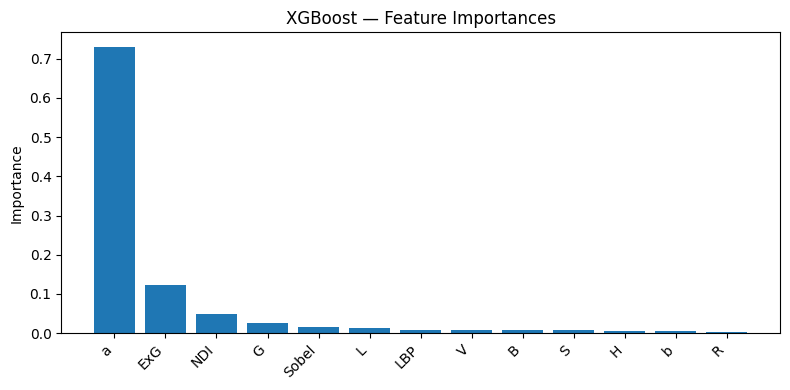

In [8]:
importances = xgb_model.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(FEATURE_NAMES)), importances[order])
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=45, ha="right")
ax.set_ylabel("Importance")
ax.set_title("XGBoost — Feature Importances")
plt.tight_layout()
plt.show()

In [9]:
print("Running inference on validation set...")
t0 = time.time()

val_gt_masks = []
val_pred_masks = []

for img_path, mask_path in zip(val_imgs, val_masks):
    img_rgb, gt_mask = load_image_mask_pair(img_path, mask_path)
    pred_mask = predict_mask(xgb_model, img_rgb)
    val_gt_masks.append(gt_mask)
    val_pred_masks.append(pred_mask)

val_inference_time = time.time() - t0
print(f"Validation inference time: {val_inference_time:.2f}s ({val_inference_time/len(val_imgs):.2f}s/image)")

Running inference on validation set...
Validation inference time: 2.81s (0.12s/image)


In [10]:
val_metrics_raw = evaluate_dataset(val_gt_masks, val_pred_masks, apply_cleanup=False)
val_metrics_cleaned = evaluate_dataset(val_gt_masks, val_pred_masks, apply_cleanup=True)

print_metrics(val_metrics_raw, "XGB - Validation (raw)")
print_metrics(val_metrics_cleaned, "XGB - Validation (after morphological cleanup)")


  XGB - Validation (raw)
  Precision    0.9251
  Recall       0.9041
  F1           0.9088
  Iou          0.8421


  XGB - Validation (after morphological cleanup)
  Precision    0.9251
  Recall       0.9041
  F1           0.9088
  Iou          0.8421



WORST CASE VS BEST CASE SCENARIOS

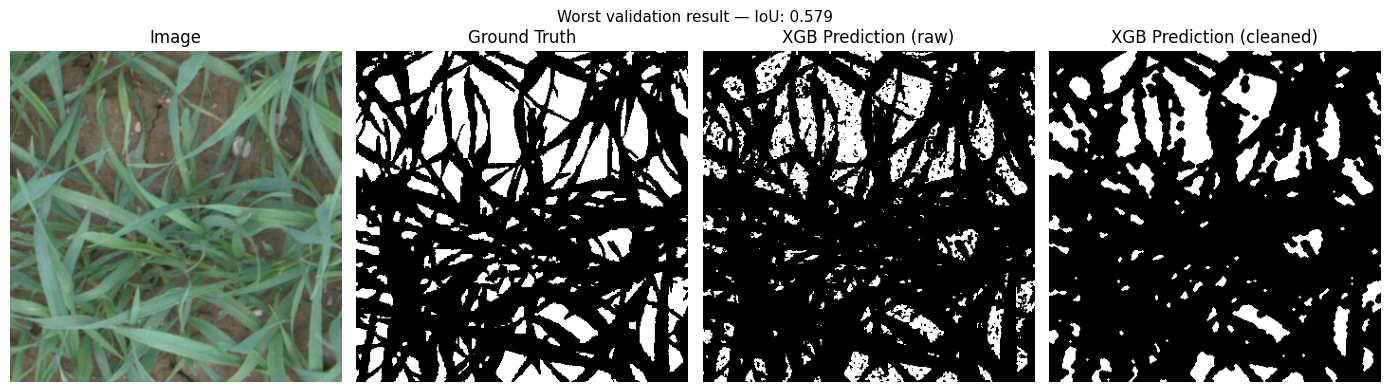

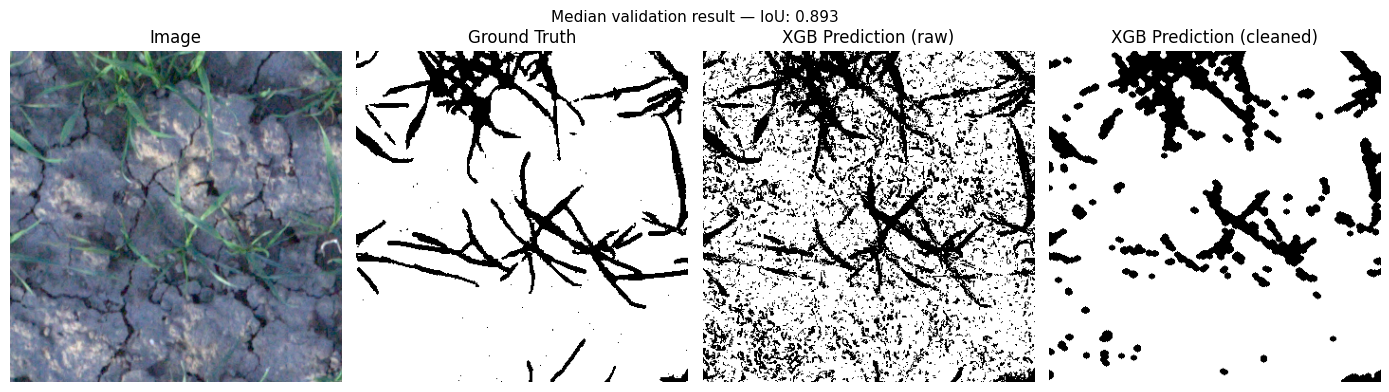

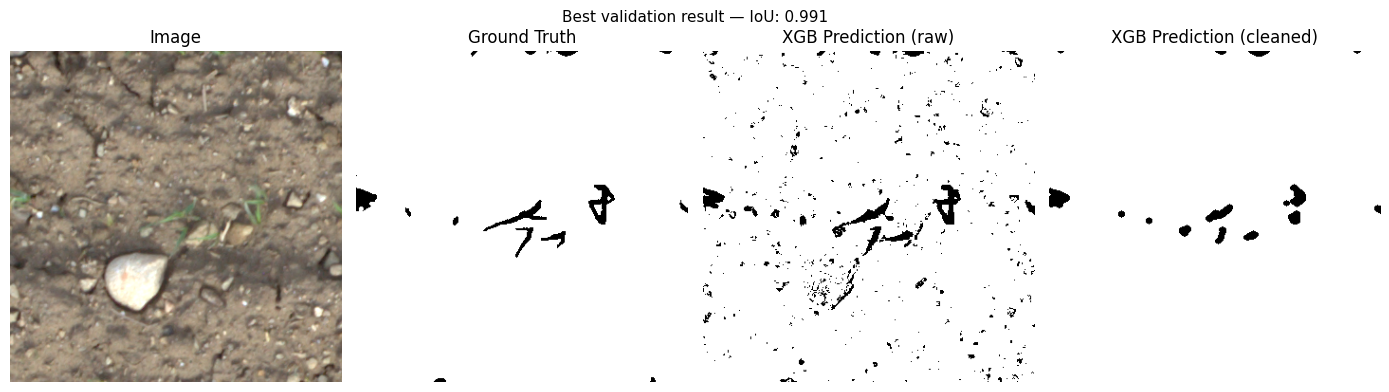

In [11]:
def visualise_predictions(img_rgb, gt_mask, pred_mask, title=""):
    cleaned = morphological_cleanup(pred_mask)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Image")

    axes[1].imshow(gt_mask, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("XGB Prediction (raw)")

    axes[3].imshow(cleaned, cmap="gray")
    axes[3].set_title("XGB Prediction (cleaned)")

    for ax in axes:
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=11)

    plt.tight_layout()
    plt.show()


val_ious = [m["iou"] for m in val_metrics_raw["per_image"]]
order = np.argsort(val_ious)

for label, idx in [("Worst", order[0]), ("Median", order[len(order)//2]), ("Best", order[-1])]:
    img_rgb, gt_mask = load_image_mask_pair(val_imgs[idx], val_masks[idx])
    visualise_predictions(
        img_rgb, gt_mask, val_pred_masks[idx],
        title=f"{label} validation result — IoU: {val_ious[idx]:.3f}"
    )

DISTORTION TEST

In [12]:
baseline_ious = []

print(f"Found {len(val_imgs)} validation images")
for img_path, mask_path in zip(val_imgs, val_masks):
    img_rgb, gt_mask = load_image_mask_pair(img_path, mask_path)
    pred_mask = predict_on_image(xgb_model, img_rgb)
    m = evaluate(gt_mask, pred_mask, apply_cleanup=False)
    baseline_ious.append(m["iou"])

baseline_mean = float(np.mean(baseline_ious))
print(f"Baseline mean IoU: {baseline_mean:.4f}")

Found 24 validation images
Baseline mean IoU: 0.8282


In [13]:
results = {d: {} for d in DISTORTION_TYPES}

for distortion, severity in itertools.product(DISTORTION_TYPES, SEVERITY_LEVELS):
    ious = []

    for img_path, mask_path in zip(val_imgs, val_masks):
        img_rgb, gt_mask = load_image_mask_pair(img_path, mask_path)
        dist_img = apply_distortions(img_rgb, distortion=distortion, severity=severity)
        pred_mask = predict_on_image(xgb_model, dist_img)
        m = evaluate(gt_mask, pred_mask, apply_cleanup=False)
        ious.append(m["iou"])

    mean_iou = float(np.mean(ious))
    results[distortion][severity] = (mean_iou, ious)
    print(
        f"{distortion:12s} sev={severity} "
        f"IoU={mean_iou:.4f} drop={baseline_mean - mean_iou:+.4f}"
    )

blur         sev=1 IoU=0.8109 drop=+0.0172
blur         sev=2 IoU=0.7594 drop=+0.0687
blur         sev=3 IoU=0.7025 drop=+0.1257
noise        sev=1 IoU=0.6110 drop=+0.2172
noise        sev=2 IoU=0.4743 drop=+0.3539
noise        sev=3 IoU=0.4060 drop=+0.4221
brightness   sev=1 IoU=0.8415 drop=-0.0133
brightness   sev=2 IoU=0.8256 drop=+0.0025
brightness   sev=3 IoU=0.7325 drop=+0.0957
occlusion    sev=1 IoU=0.8210 drop=+0.0072
occlusion    sev=2 IoU=0.8105 drop=+0.0177
occlusion    sev=3 IoU=0.7799 drop=+0.0482


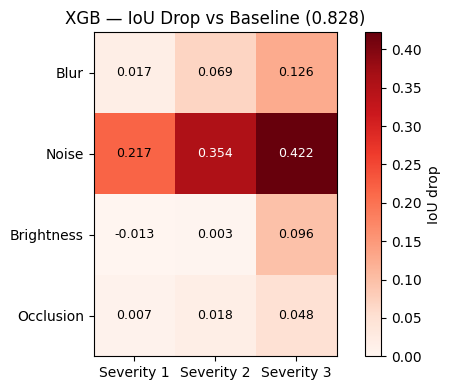

In [14]:
iou_matrix = np.array([[results[d][s][0] for s in SEVERITY_LEVELS] for d in DISTORTION_TYPES])
drop_matrix = baseline_mean - iou_matrix

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(drop_matrix, cmap="Reds", vmin=0, vmax=max(drop_matrix.max(), 0.01))

ax.set_xticks(range(len(SEVERITY_LEVELS)))
ax.set_xticklabels([f"Severity {s}" for s in SEVERITY_LEVELS])
ax.set_yticks(range(len(DISTORTION_TYPES)))
ax.set_yticklabels([d.capitalize() for d in DISTORTION_TYPES])
ax.set_title(f"XGB — IoU Drop vs Baseline ({baseline_mean:.3f})")

for i in range(len(DISTORTION_TYPES)):
    for j in range(len(SEVERITY_LEVELS)):
        val = drop_matrix[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val > drop_matrix.max() * 0.6 else "black", fontsize=9)

plt.colorbar(im, ax=ax, label="IoU drop")
plt.tight_layout()
plt.show()

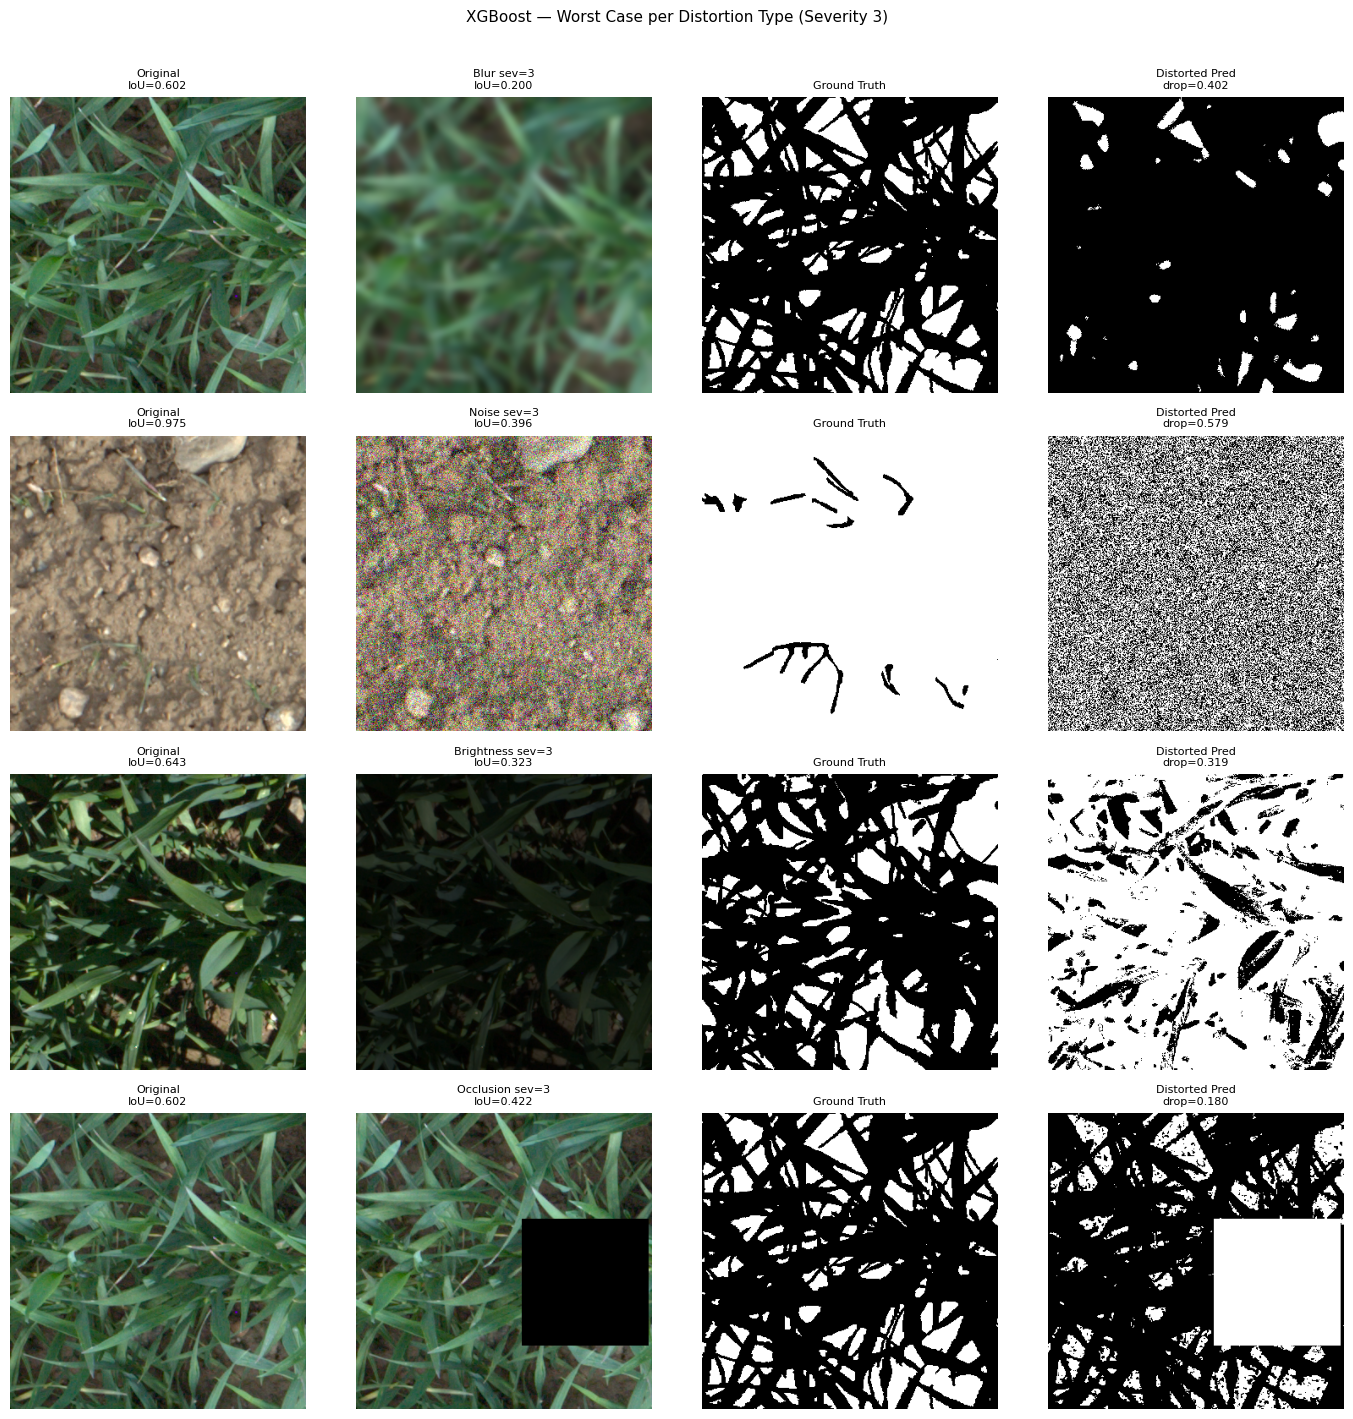

In [15]:
fig, axes = plt.subplots(len(DISTORTION_TYPES), 4, figsize=(14, 3.5 * len(DISTORTION_TYPES)))

for row, distortion in enumerate(DISTORTION_TYPES):
    _, per_img_ious = results[distortion][3]
    drops = [baseline_ious[i] - per_img_ious[i] for i in range(len(val_imgs))]
    worst_idx = int(np.argmax(drops))

    img_rgb, gt_mask = load_image_mask_pair(val_imgs[worst_idx], val_masks[worst_idx])
    dist_img = apply_distortions(img_rgb, distortion=distortion, severity=3)
    pred_dist = predict_on_image(xgb_model, dist_img)

    panels = [
        (img_rgb, f"Original\nIoU={baseline_ious[worst_idx]:.3f}"),
        (dist_img, f"{distortion.capitalize()} sev=3\nIoU={per_img_ious[worst_idx]:.3f}"),
        (gt_mask * 255, "Ground Truth"),
        (pred_dist * 255, f"Distorted Pred\ndrop={drops[worst_idx]:.3f}"),
    ]

    for col, (panel, title) in enumerate(panels):
        ax = axes[row, col]
        ax.imshow(panel, cmap="gray" if panel.ndim == 2 else None)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

plt.suptitle("XGBoost — Worst Case per Distortion Type (Severity 3)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

TEST SET EVALUATION

In [16]:
gt_masks, pred_masks = [], []
for img_path, mask_path in zip(test_imgs, test_masks):
    img_rgb, gt_mask = load_image_mask_pair(img_path, mask_path)
    X = extract_features(img_rgb)
    y_pred = xgb_model.predict(X)
    pred_mask = reshape_mask(y_pred, 350, 350)

    gt_masks.append(gt_mask)
    pred_masks.append(pred_mask)

test_metrics_raw = evaluate_dataset(gt_masks, pred_masks, apply_cleanup=False)
test_metrics_cleaned = evaluate_dataset(gt_masks, pred_masks, apply_cleanup=True)

print_metrics(test_metrics_raw, "XGBoost — Test Set")
print_metrics(test_metrics_cleaned, "XGB — Test Set (after morphological cleanup)")


  XGBoost — Test Set
  Precision    0.9219
  Recall       0.9135
  F1           0.9132
  Iou          0.8454


  XGB — Test Set (after morphological cleanup)
  Precision    0.9219
  Recall       0.9135
  F1           0.9132
  Iou          0.8454

